# IMDB Title Rating Prediction

Predict the IMDB average rating of movies and TV titles using genre, title type, release year, and vote count.

**Target**: `averageRating` — continuous (regression)

**Pipeline**
1. Data Loading & Inspection
2. Exploratory Data Analysis
3. Feature Engineering
4. Preprocessing
5. Model Training & Evaluation (two variants: with and without `numVotes`)
6. Hyperparameter Optimization
7. Final Evaluation & Feature Importance

## 1. Data Loading & Inspection

In [31]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

from sklearn.model_selection import train_test_split, cross_val_score, RandomizedSearchCV
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import Ridge
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

warnings.filterwarnings('ignore')
sns.set_theme(style='darkgrid', palette='muted')
plt.rcParams['figure.dpi'] = 100

SEED = 42

In [32]:
df = pd.read_csv('data/title_combined.csv')

print(f'Shape: {df.shape}')
print(f'\nColumn dtypes:')
print(df.dtypes)
print(f'\nMissing values:')
print(df.isnull().sum())

Shape: (9999, 6)

Column dtypes:
title                str
titleType            str
genres               str
numVotes           int64
year               int64
averageRating    float64
dtype: object

Missing values:
title            0
titleType        0
genres           1
numVotes         0
year             0
averageRating    0
dtype: int64


In [33]:
df.head()

,title,titleType,genres,numVotes,year,averageRating
0,The Shawshank Redemption,movie,Drama,3185932,1994,9.3
1,The Dark Knight,movie,"Action,Crime,Drama",3165032,2008,9.1
2,Inception,movie,"Action,Adventure,Sci-Fi",2814573,2010,8.8
3,Game of Thrones,tvSeries,"Action,Adventure,Drama",2611980,2011,9.2
4,Breaking Bad,tvSeries,"Crime,Drama,Thriller",2611328,2008,9.5


In [34]:
df.describe()

,numVotes,year,averageRating
count,9.999000e+03,9999.00000,9999.000000
mean,1.215959e+05,2005.50495,6.849405
std,2.002060e+05,16.87822,1.046733
min,2.017100e+04,1902.00000,1.000000
25%,3.065550e+04,1999.00000,6.200000
50%,5.417300e+04,2010.00000,6.900000
75%,1.228770e+05,2018.00000,7.600000
max,3.185932e+06,2026.00000,9.800000


**Key observations**
- 1 null in `genres` — will fill with `'Unknown'`.
- `genres` is a comma-separated multi-label field (e.g. `'Action,Crime,Drama'`) — will be multi-hot encoded across 28 unique genres.
- `numVotes` has moderate correlation with `averageRating` (r ≈ 0.25). It is a partially post-hoc signal — popular films attract more votes and tend to have self-reinforcing high ratings — but it is technically available at prediction time. We train **two variants**: one with `numVotes` and one without, to understand what the model actually learns.
- `title` is free text with no direct predictive signal in this feature set; excluded.

## 2. Exploratory Data Analysis

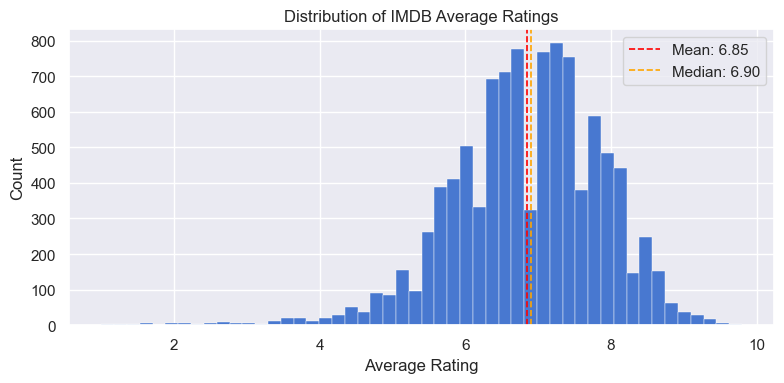

In [35]:
fig, ax = plt.subplots(figsize=(8, 4))
ax.hist(df['averageRating'], bins=50, edgecolor='white', linewidth=0.3)
ax.axvline(df['averageRating'].mean(), color='red', linestyle='--', linewidth=1.2,
           label=f'Mean: {df["averageRating"].mean():.2f}')
ax.axvline(df['averageRating'].median(), color='orange', linestyle='--', linewidth=1.2,
           label=f'Median: {df["averageRating"].median():.2f}')
ax.set_xlabel('Average Rating')
ax.set_ylabel('Count')
ax.set_title('Distribution of IMDB Average Ratings')
ax.legend()
plt.tight_layout()
plt.show()

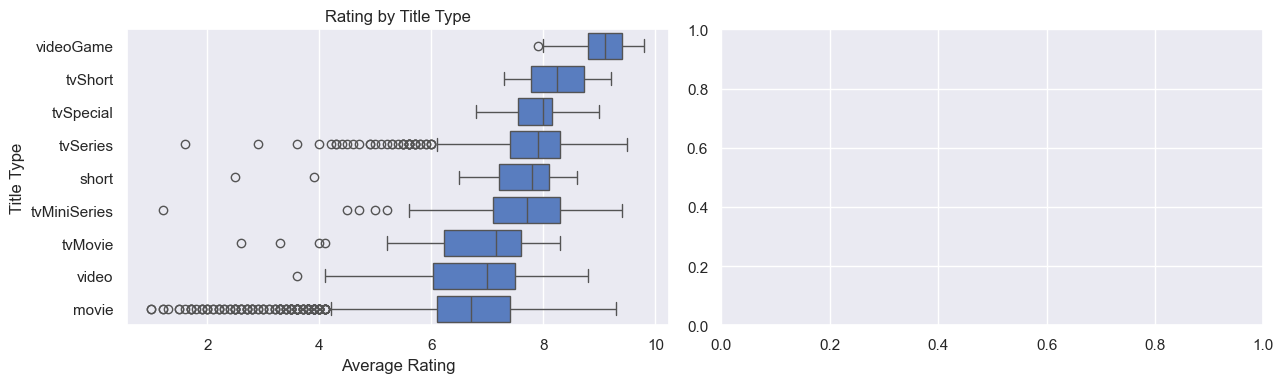

<Figure size 640x480 with 0 Axes>

In [36]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# Calculate the ordered categories based on median rating
type_order = df.groupby('titleType')['averageRating'].median().sort_values(ascending=False).index

# Plot horizontal boxplot on the first subplot
sns.boxplot(
    data=df, 
    x='averageRating', 
    y='titleType', 
    ax=axes[0], 
    order=type_order, 
    patch_artist=True)

# 3. Format aesthetics (Redundant title lines removed)
axes[0].set_title('Rating by Title Type')
axes[0].set_xlabel('Average Rating')
axes[0].set_ylabel('Title Type')

plt.tight_layout()
plt.show()

# Rating over decades
df['decade'] = (df['year'] // 10 * 10).astype(str)
decade_order = sorted(df['decade'].unique())
decade_means = df.groupby('decade')['averageRating'].mean().reindex(decade_order)
axes[1].plot(decade_means.index, decade_means.values, marker='o')
axes[1].set_xlabel('Decade')
axes[1].set_ylabel('Mean Rating')
axes[1].set_title('Mean Rating by Decade')
axes[1].tick_params(axis='x', rotation=45)

plt.suptitle('')
plt.tight_layout()
plt.show()

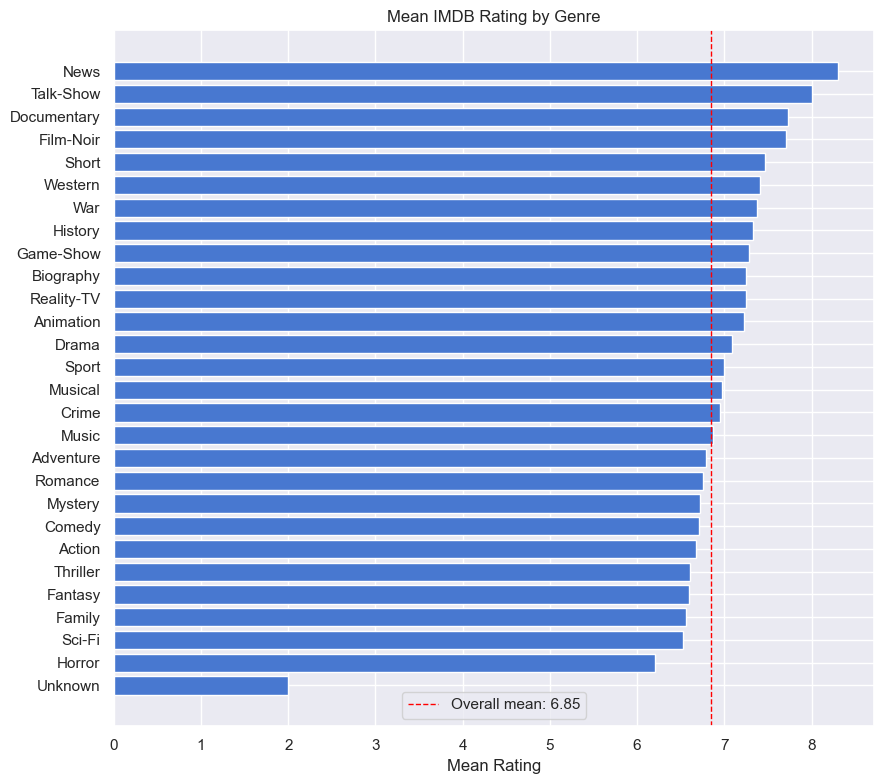

In [37]:
# Expand multi-label genres and compute mean rating per genre
df_genres = df.copy()
df_genres['genres'] = df_genres['genres'].fillna('Unknown')
genre_exploded = df_genres.assign(genre=df_genres['genres'].str.split(',')).explode('genre')
genre_exploded['genre'] = genre_exploded['genre'].str.strip()

genre_stats = (
    genre_exploded.groupby('genre')['averageRating']
    .agg(['mean', 'count'])
    .sort_values('mean', ascending=True)
)

fig, ax = plt.subplots(figsize=(9, 8))
ax.barh(genre_stats.index, genre_stats['mean'])
ax.set_xlabel('Mean Rating')
ax.set_title('Mean IMDB Rating by Genre')
ax.axvline(df['averageRating'].mean(), color='red', linestyle='--', linewidth=1,
           label=f'Overall mean: {df["averageRating"].mean():.2f}')
ax.legend()
plt.tight_layout()
plt.show()

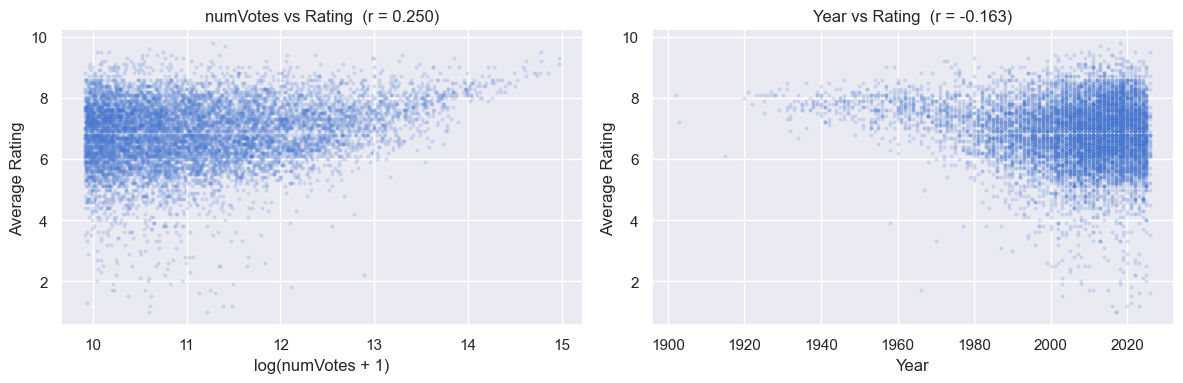

In [38]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].scatter(np.log1p(df['numVotes']), df['averageRating'],
                alpha=0.2, s=8, linewidths=0)
axes[0].set_xlabel('log(numVotes + 1)')
axes[0].set_ylabel('Average Rating')
axes[0].set_title(f'numVotes vs Rating  (r = {df["numVotes"].corr(df["averageRating"]):.3f})')

axes[1].scatter(df['year'], df['averageRating'],
                alpha=0.2, s=8, linewidths=0)
axes[1].set_xlabel('Year')
axes[1].set_ylabel('Average Rating')
axes[1].set_title(f'Year vs Rating  (r = {df["year"].corr(df["averageRating"]):.3f})')

plt.tight_layout()
plt.show()

## 3. Feature Engineering

In [39]:
df['genres'] = df['genres'].fillna('Unknown')

# Multi-hot encode genres — each title can belong to multiple genres
ALL_GENRES = sorted(
    df['genres'].str.split(',').explode().str.strip().unique()
)

for genre in ALL_GENRES:
    df[f'genre_{genre}'] = df['genres'].str.contains(genre, regex=False).astype(int)

# Number of genres a title belongs to
df['num_genres'] = df['genres'].str.split(',').str.len()

# Log-transform numVotes to compress the heavy right skew
df['log_numVotes'] = np.log1p(df['numVotes'])

# Title age relative to dataset snapshot year
SNAPSHOT_YEAR = df['year'].max()
df['title_age'] = SNAPSHOT_YEAR - df['year']

# Era buckets
df['era'] = pd.cut(
    df['year'],
    bins=[1900, 1950, 1970, 1990, 2000, 2010, 2020, 2030],
    labels=['Pre-1950', '1950s-60s', '1970s-80s', '1990s', '2000s', '2010s', '2020s']
).astype(str)

genre_cols = [f'genre_{g}' for g in ALL_GENRES]
print(f'Genre indicator columns: {len(genre_cols)}')
print(f'num_genres sample: {df["num_genres"].value_counts().head()}')

Genre indicator columns: 28
num_genres sample: num_genres
3    7024
2    2226
1     749
Name: count, dtype: int64


## 4. Preprocessing

In [40]:
TARGET = 'averageRating'

# Columns to drop: identifiers, raw genre string (replaced by indicators),
# raw numVotes (replaced by log version), decade (redundant with era)
DROP_COLS = ['title', 'genres', 'numVotes', 'decade']

NUMERIC_FEATURES   = ['year', 'title_age', 'num_genres', 'log_numVotes'] + genre_cols
NUMERIC_NO_VOTES   = ['year', 'title_age', 'num_genres'] + genre_cols
CATEGORICAL_FEATURES = ['titleType', 'era']

X_full = df.drop(columns=[TARGET] + DROP_COLS)
y      = df[TARGET]

X_train, X_test, y_train, y_test = train_test_split(
    X_full, y, test_size=0.2, random_state=SEED
)
print(f'Train: {X_train.shape}  |  Test: {X_test.shape}')

Train: (7999, 34)  |  Test: (2000, 34)


In [41]:
def build_preprocessor(numeric_features, categorical_features):
    numeric_transformer = Pipeline(steps=[
        ('scaler', StandardScaler())
    ])
    categorical_transformer = Pipeline(steps=[
        ('encoder', OneHotEncoder(handle_unknown='ignore', sparse_output=False))
    ])
    return ColumnTransformer(transformers=[
        ('num', numeric_transformer,  numeric_features),
        ('cat', categorical_transformer, categorical_features),
    ])

preprocessor_full     = build_preprocessor(NUMERIC_FEATURES,   CATEGORICAL_FEATURES)
preprocessor_no_votes = build_preprocessor(NUMERIC_NO_VOTES,   CATEGORICAL_FEATURES)

## 5. Model Training & Evaluation

Two variants per model:
- **Full**: includes `log_numVotes`
- **No-Votes**: excludes `log_numVotes` — purer test of genre/type/year signal

In [42]:
def evaluate(name, model, X_tr, y_tr, X_te, y_te):
    model.fit(X_tr, y_tr)
    preds = model.predict(X_te)
    mae   = mean_absolute_error(y_te, preds)
    rmse = np.sqrt(mean_squared_error(y_te, preds))
    r2    = r2_score(y_te, preds)
    cv    = cross_val_score(model, X_tr, y_tr, cv=5,
                            scoring='neg_root_mean_squared_error', n_jobs=-1)
    print(f'{name}')
    print(f'  MAE  : {mae:.4f}')
    print(f'  RMSE : {rmse:.4f}')
    print(f'  R²   : {r2:.4f}')
    print(f'  CV RMSE (5-fold): {-cv.mean():.4f} ± {cv.std():.4f}')
    print()
    return {'name': name, 'MAE': mae, 'RMSE': rmse, 'R2': r2}

In [43]:
print(' With numVotes')
results_full = []
fitted_full  = {}

models_def = {
    'Ridge'             : Ridge(alpha=1.0),
    'Random Forest'     : RandomForestRegressor(n_estimators=100, random_state=SEED, n_jobs=-1),
    'Gradient Boosting' : GradientBoostingRegressor(n_estimators=200, random_state=SEED),
}

for name, est in models_def.items():
    pipe = Pipeline([('pre', preprocessor_full), ('model', est)])
    res  = evaluate(f'{name} (full)', pipe, X_train, y_train, X_test, y_test)
    results_full.append(res)
    fitted_full[name] = pipe

 With numVotes
Ridge (full)
  MAE  : 0.5500
  RMSE : 0.7719
  R²   : 0.4385
  CV RMSE (5-fold): 0.7794 ± 0.0300

Random Forest (full)
  MAE  : 0.5499
  RMSE : 0.7870
  R²   : 0.4164
  CV RMSE (5-fold): 0.7766 ± 0.0319

Gradient Boosting (full)
  MAE  : 0.5229
  RMSE : 0.7446
  R²   : 0.4776
  CV RMSE (5-fold): 0.7495 ± 0.0314



In [44]:
print('=== WITHOUT numVotes ===')
results_nov = []
fitted_nov  = {}

models_def2 = {
    'Ridge'             : Ridge(alpha=1.0),
    'Random Forest'     : RandomForestRegressor(n_estimators=100, random_state=SEED, n_jobs=-1),
    'Gradient Boosting' : GradientBoostingRegressor(n_estimators=200, random_state=SEED),
}

for name, est in models_def2.items():
    pipe = Pipeline([('pre', preprocessor_no_votes), ('model', est)])
    res  = evaluate(f'{name} (no votes)', pipe, X_train, y_train, X_test, y_test)
    results_nov.append(res)
    fitted_nov[name] = pipe

=== WITHOUT numVotes ===
Ridge (no votes)
  MAE  : 0.6209
  RMSE : 0.8450
  R²   : 0.3273
  CV RMSE (5-fold): 0.8467 ± 0.0266

Random Forest (no votes)
  MAE  : 0.6653
  RMSE : 0.9048
  R²   : 0.2286
  CV RMSE (5-fold): 0.9099 ± 0.0311

Gradient Boosting (no votes)
  MAE  : 0.6044
  RMSE : 0.8280
  R²   : 0.3540
  CV RMSE (5-fold): 0.8321 ± 0.0256



In [45]:
comparison = pd.DataFrame(results_full + results_nov).sort_values('RMSE')
print(comparison.to_string(index=False))

                        name      MAE     RMSE       R2
    Gradient Boosting (full) 0.522937 0.744620 0.477551
                Ridge (full) 0.549965 0.771922 0.438537
        Random Forest (full) 0.549879 0.787025 0.416352
Gradient Boosting (no votes) 0.604357 0.828004 0.353990
            Ridge (no votes) 0.620876 0.844960 0.327261
    Random Forest (no votes) 0.665281 0.904796 0.228607


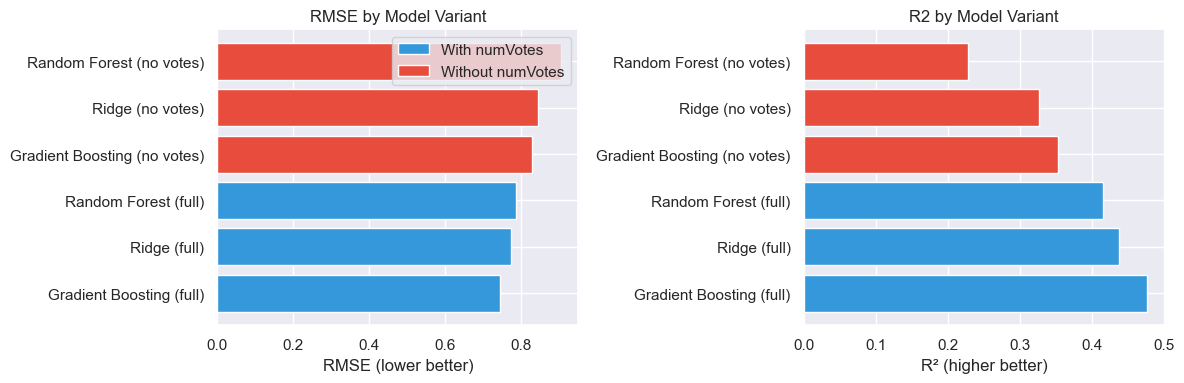

In [46]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

for ax, col, label in zip(axes, ['RMSE', 'R2'], ['RMSE (lower better)', 'R² (higher better)']):
    comp_sorted = comparison.sort_values(col, ascending=(col == 'RMSE'))
    colors = ['#3498db' if '(full)' in n else '#e74c3c' for n in comp_sorted['name']]
    ax.barh(comp_sorted['name'], comp_sorted[col], color=colors)
    ax.set_xlabel(label)
    ax.set_title(f'{col} by Model Variant')

from matplotlib.patches import Patch
legend_elements = [Patch(facecolor='#3498db', label='With numVotes'),
                   Patch(facecolor='#e74c3c', label='Without numVotes')]
axes[0].legend(handles=legend_elements)

plt.tight_layout()
plt.show()

## 6. Hyperparameter Optimization

Tune Gradient Boosting on the full feature set (best-performing variant).

In [47]:
param_dist = {
    'model__n_estimators'      : [100, 200, 300, 400],
    'model__learning_rate'     : [0.01, 0.05, 0.1, 0.15],
    'model__max_depth'         : [3, 4, 5, 6],
    'model__min_samples_split' : [2, 5, 10],
    'model__subsample'         : [0.7, 0.8, 0.9, 1.0],
    'model__max_features'      : ['sqrt', 'log2', None],
}

gb_pipe = Pipeline([
    ('pre',   build_preprocessor(NUMERIC_FEATURES, CATEGORICAL_FEATURES)),
    ('model', GradientBoostingRegressor(random_state=SEED))
])

search = RandomizedSearchCV(
    gb_pipe,
    param_distributions=param_dist,
    n_iter=40,
    cv=5,
    scoring='neg_root_mean_squared_error',
    random_state=SEED,
    n_jobs=-1,
    verbose=1
)

search.fit(X_train, y_train)
print('\nBest params:', search.best_params_)
print(f'Best CV RMSE: {-search.best_score_:.4f}')

Fitting 5 folds for each of 40 candidates, totalling 200 fits

Best params: {'model__subsample': 0.9, 'model__n_estimators': 400, 'model__min_samples_split': 5, 'model__max_features': 'log2', 'model__max_depth': 4, 'model__learning_rate': 0.05}
Best CV RMSE: 0.7438


## 7. Final Evaluation & Feature Importance

In [49]:
best_model = search.best_estimator_
y_pred     = best_model.predict(X_test)

final_mae  = mean_absolute_error(y_test, y_pred)
final_rmse = np.sqrt(mean_squared_error(y_test, y_pred))
final_r2   = r2_score(y_test, y_pred)

print('Tuned Gradient Boosting (Full) — Test Set ')
print(f'MAE  : {final_mae:.4f}')
print(f'RMSE : {final_rmse:.4f}')
print(f'R²   : {final_r2:.4f}')

Tuned Gradient Boosting (Full) — Test Set 
MAE  : 0.5128
RMSE : 0.7377
R²   : 0.4872


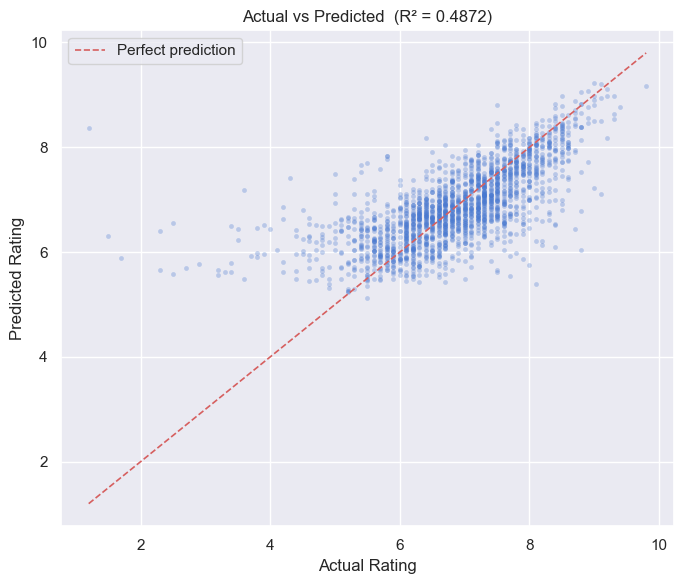

In [50]:
fig, ax = plt.subplots(figsize=(7, 6))
ax.scatter(y_test, y_pred, alpha=0.3, s=12, linewidths=0)
lims = [min(y_test.min(), y_pred.min()), max(y_test.max(), y_pred.max())]
ax.plot(lims, lims, 'r--', linewidth=1.2, label='Perfect prediction')
ax.set_xlabel('Actual Rating')
ax.set_ylabel('Predicted Rating')
ax.set_title(f'Actual vs Predicted  (R² = {final_r2:.4f})')
ax.legend()
plt.tight_layout()
plt.show()

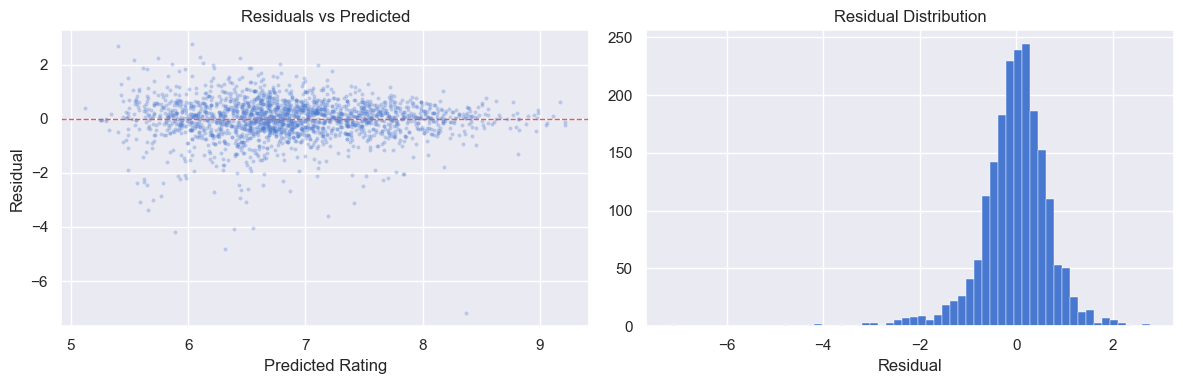

In [51]:
residuals = y_test - y_pred

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].scatter(y_pred, residuals, alpha=0.3, s=8, linewidths=0)
axes[0].axhline(0, color='r', linestyle='--', linewidth=1)
axes[0].set_xlabel('Predicted Rating')
axes[0].set_ylabel('Residual')
axes[0].set_title('Residuals vs Predicted')

axes[1].hist(residuals, bins=60, edgecolor='white', linewidth=0.3)
axes[1].set_xlabel('Residual')
axes[1].set_title('Residual Distribution')

plt.tight_layout()
plt.show()

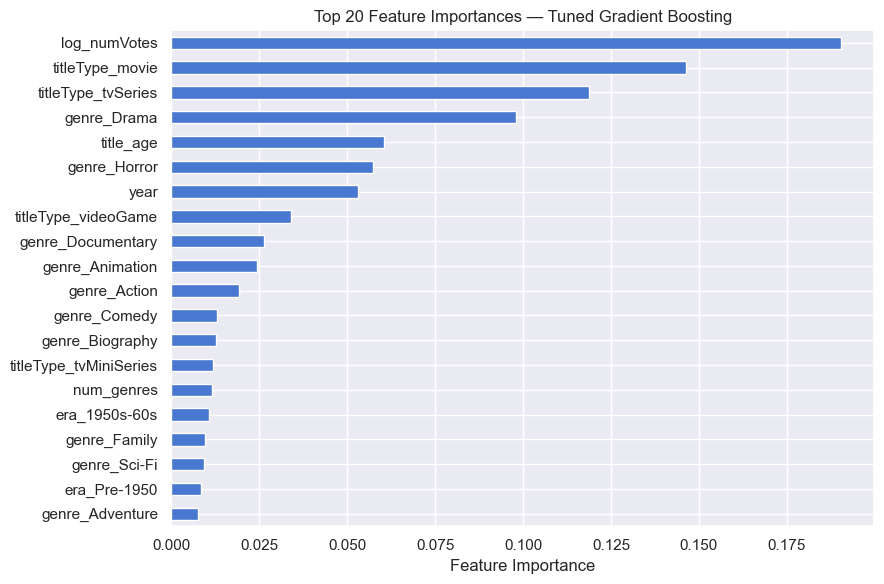

In [52]:
# Feature names post-encoding
ohe_cols = (
    best_model.named_steps['pre']
    .named_transformers_['cat']
    .named_steps['encoder']
    .get_feature_names_out(CATEGORICAL_FEATURES)
)
feature_names = NUMERIC_FEATURES + list(ohe_cols)

importances = best_model.named_steps['model'].feature_importances_
feat_df = (
    pd.Series(importances, index=feature_names)
    .sort_values(ascending=False)
    .head(20)
)

fig, ax = plt.subplots(figsize=(9, 6))
feat_df.sort_values().plot(kind='barh', ax=ax)
ax.set_xlabel('Feature Importance')
ax.set_title('Top 20 Feature Importances — Tuned Gradient Boosting')
plt.tight_layout()
plt.show()

In [53]:
print('Top 10 features:')
print(feat_df.head(10).to_string())

Top 10 features:
log_numVotes           0.190280
titleType_movie        0.146418
titleType_tvSeries     0.118692
genre_Drama            0.098047
title_age              0.060521
genre_Horror           0.057486
year                   0.052972
titleType_videoGame    0.034062
genre_Documentary      0.026421
genre_Animation        0.024336
